<a href="https://colab.research.google.com/github/SaiRohith369/mypythonproject/blob/main/ayushman_fraud_detection_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("ayushman_synthetic_claims.csv")
df.head()

,Claim_ID,Patient_ID,Hospital_ID,Doctor_ID,Procedure_Code,Claim_Amount,Length_of_Stay,Admission_Date,City,Fraud_Label
0,C0,P103,H71,D126,PROC1,16490,4,2025-03-13,Hyderabad,0
1,C1,P357,H109,D17,PROC5,38893,1,2025-02-17,Warangal,0
2,C2,P2070,H7,D288,PROC2,33886,4,2025-11-29,Khammam,0
3,C3,P903,H115,D302,PROC4,26092,5,2025-01-04,Warangal,0
4,C4,P1394,H72,D80,PROC4,19063,4,2025-06-22,Hyderabad,0


In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=150,
    contamination=0.05,
    random_state=42
)

model.fit(X)

# Predict anomalies
df["Anomaly_Score"] = model.decision_function(X)
df["Fraud_Prediction"] = model.predict(X)

# Convert prediction (-1 anomaly, 1 normal)
df["Fraud_Prediction"] = df["Fraud_Prediction"].map({1: 0, -1: 1})

df[["Claim_ID", "Risk_Score" if "Risk_Score" in df.columns else "Anomaly_Score", "Fraud_Prediction"]].head()

,Claim_ID,Anomaly_Score,Fraud_Prediction
0,C0,0.120097,0
1,C1,0.060619,0
2,C2,0.098751,0
3,C3,0.069799,0
4,C4,0.107949,0


In [ ]:
df["Fraud_Prediction"].value_counts()

,count
Fraud_Prediction,
0,9690
1,510


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(df["Fraud_Label"], df["Fraud_Prediction"]))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      9790
           1       0.20      0.25      0.22       410

    accuracy                           0.93     10200
   macro avg       0.59      0.60      0.59     10200
weighted avg       0.94      0.93      0.93     10200



In [ ]:
# Rule 1: Extremely high claim amount (2x procedure average)

procedure_avg = df.groupby("Procedure_Code")["Claim_Amount"].transform("mean")
df["High_Amount_Flag"] = (df["Claim_Amount"] > 2 * procedure_avg).astype(int)

# Rule 2: Suspicious doctor frequency (top 5%)
doctor_threshold = df["Doctor_Freq"].quantile(0.95)
df["High_Doctor_Flag"] = (df["Doctor_Freq"] > doctor_threshold).astype(int)

# Rule 3: Suspicious hospital frequency (top 5%)
hospital_threshold = df["Hospital_Freq"].quantile(0.95)
df["High_Hospital_Flag"] = (df["Hospital_Freq"] > hospital_threshold).astype(int)

# Rule 4: Very short stay but high amount
df["Short_Stay_High_Bill"] = (
    (df["Length_of_Stay"] <= 1) &
    (df["Claim_Amount"] > df["Claim_Amount"].quantile(0.75))
).astype(int)

df.head()

,Claim_ID,Patient_ID,Hospital_ID,Doctor_ID,Procedure_Code,Claim_Amount,Length_of_Stay,Admission_Date,City,Fraud_Label,Day_of_Year,Patient_Freq,Doctor_Freq,Hospital_Freq,Anomaly_Score,Fraud_Prediction,High_Amount_Flag,High_Doctor_Flag,High_Hospital_Flag,Short_Stay_High_Bill
0,C0,P103,H71,D126,PROC1,16490,4,2025-03-13,Hyderabad,0,72,3,26,72,0.120097,0,0,0,0,0
1,C1,P357,H109,D17,PROC5,38893,1,2025-02-17,Warangal,0,48,4,29,78,0.060619,0,0,0,0,0
2,C2,P2070,H7,D288,PROC2,33886,4,2025-11-29,Khammam,0,333,3,31,72,0.098751,0,0,0,0,0
3,C3,P903,H115,D302,PROC4,26092,5,2025-01-04,Warangal,0,4,5,24,78,0.069799,0,0,0,0,0
4,C4,P1394,H72,D80,PROC4,19063,4,2025-06-22,Hyderabad,0,173,6,32,65,0.107949,0,0,0,0,0


In [ ]:
# Normalize ML risk score first (if not already done)

min_score = df["Anomaly_Score"].min()
max_score = df["Anomaly_Score"].max()

df["ML_Risk"] = 100 * (1 - (df["Anomaly_Score"] - min_score) / (max_score - min_score))

# Rule-based risk score (each flag adds 15 points)
df["Rule_Risk"] = (
    df["High_Amount_Flag"] * 15 +
    df["High_Doctor_Flag"] * 15 +
    df["High_Hospital_Flag"] * 15 +
    df["Short_Stay_High_Bill"] * 15
)

# Final Hybrid Risk Score
df["Final_Risk_Score"] = (0.6 * df["ML_Risk"]) + (0.4 * df["Rule_Risk"])

df["Final_Risk_Score"] = df["Final_Risk_Score"].clip(0, 100)

df[["Final_Risk_Score"]].head()

,Final_Risk_Score
0,7.089281
1,21.351927
2,12.208086
3,19.150530
4,10.002245


In [ ]:
df["Hybrid_Prediction"] = (df["Final_Risk_Score"] > 60).astype(int)

df["Hybrid_Prediction"].value_counts()

,count
Hybrid_Prediction,
0,10187
1,13


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df["Fraud_Label"], df["Hybrid_Prediction"]))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      9790
           1       0.31      0.01      0.02       410

    accuracy                           0.96     10200
   macro avg       0.63      0.50      0.50     10200
weighted avg       0.93      0.96      0.94     10200



In [ ]:
# Find how many real fraud cases exist
fraud_count = df["Fraud_Label"].sum()
total_count = len(df)

fraud_ratio = fraud_count / total_count
print("Fraud Ratio:", fraud_ratio)

Fraud Ratio: 0.04019607843137255


In [ ]:
# Use real fraud ratio to set threshold
threshold = df["Final_Risk_Score"].quantile(1 - fraud_ratio)

df["Hybrid_Fraud_Prediction"] = (df["Final_Risk_Score"] > threshold).astype(int)

df["Hybrid_Fraud_Prediction"].value_counts()

,count
Hybrid_Fraud_Prediction,
0,9790
1,410


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(df["Fraud_Label"], df["Hybrid_Fraud_Prediction"]))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      9790
           1       0.20      0.20      0.20       410

    accuracy                           0.94     10200
   macro avg       0.58      0.58      0.58     10200
weighted avg       0.94      0.94      0.94     10200



In [ ]:
import networkx as nx

G = nx.Graph()

# Add edges: Patient ↔ Doctor
for _, row in df.iterrows():
    G.add_edge(row["Patient_ID"], row["Doctor_ID"])
    G.add_edge(row["Doctor_ID"], row["Hospital_ID"])

print("Total Nodes:", G.number_of_nodes())
print("Total Edges:", G.number_of_edges())


Total Nodes: 3446
Total Edges: 19147


In [ ]:
# Compute degree centrality
centrality = nx.degree_centrality(G)

# Convert to dataframe
centrality_df = pd.DataFrame.from_dict(centrality, orient='index', columns=["Centrality"])

# Filter only doctors
doctor_centrality = centrality_df[centrality_df.index.str.startswith("D")]

# Top suspicious doctors
top_doctors = doctor_centrality.sort_values(by="Centrality", ascending=False).head(10)

top_doctors

,Centrality
D252,0.021771
D295,0.021480
D342,0.020610
D291,0.020610
D175,0.020610
D31,0.020319
D4,0.020029
D99,0.019739
D8,0.019739
D176,0.019448


In [ ]:
# Threshold top 5% centrality
threshold = doctor_centrality["Centrality"].quantile(0.95)

suspicious_doctors = doctor_centrality[
    doctor_centrality["Centrality"] > threshold
]

suspicious_doctors

,Centrality
D4,0.020029
D8,0.019739
D154,0.019158
D342,0.020610
D99,0.019739
D356,0.018578
D200,0.018868
D393,0.019158
D295,0.021480
D31,0.020319


In [ ]:
doctor_centrality.loc["D25"]

,D25
Centrality,0.017997


In [ ]:
# Compute average risk per doctor
doctor_risk = df.groupby("Doctor_ID")["Final_Risk_Score"].mean().reset_index()

# Sort highest risk doctors
doctor_risk = doctor_risk.sort_values(by="Final_Risk_Score", ascending=False)

doctor_risk.head(10)

,Doctor_ID,Final_Risk_Score
270,D342,44.685610
135,D220,41.060013
170,D252,40.740373
399,D99,40.500926
217,D295,40.452078
234,D31,40.219452
42,D137,38.872768
142,D227,37.467463
326,D393,37.200424
213,D291,36.975543


In [ ]:
# Merge centrality with risk score
doctor_combined = doctor_risk.merge(
    doctor_centrality.reset_index(),
    left_on="Doctor_ID",
    right_on="index"
)

doctor_combined = doctor_combined.rename(columns={"Centrality": "Graph_Centrality"})

# Create combined fraud score
doctor_combined["Combined_Score"] = (
    doctor_combined["Final_Risk_Score"] * 0.7 +
    doctor_combined["Graph_Centrality"] * 100 * 0.3
)

doctor_combined = doctor_combined.sort_values(by="Combined_Score", ascending=False)

doctor_combined.head(10)

,Doctor_ID,Final_Risk_Score,index,Graph_Centrality,Combined_Score
0,D342,44.685610,D342,0.020610,31.898214
2,D252,40.740373,D252,0.021771,29.171381
4,D295,40.452078,D295,0.021480,28.960867
1,D220,41.060013,D220,0.006967,28.951007
3,D99,40.500926,D99,0.019739,28.942811
5,D31,40.219452,D31,0.020319,28.763196
6,D137,38.872768,D137,0.006386,27.402519
8,D393,37.200424,D393,0.019158,26.615043
9,D291,36.975543,D291,0.020610,26.501168
7,D227,37.467463,D227,0.004935,26.375265


In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px
import plotly.graph_objects as go


In [ ]:
top_doctors = df.groupby("Doctor_ID")["Final_Risk_Score"].mean().reset_index()
top_doctors = top_doctors.sort_values(by="Final_Risk_Score", ascending=False).head(10)

fig = px.bar(
    top_doctors,
    x="Doctor_ID",
    y="Final_Risk_Score",
    title="Top Suspicious Doctors",
)

fig.show()

In [ ]:
fig = px.histogram(
    df,
    x="Final_Risk_Score",
    nbins=30,
    title="Risk Score Distribution"
)

fig.show()


In [ ]:
fig = px.pie(
    df,
    names="Fraud_Label",
    title="Fraud vs Legit Claims"
)

fig.show()

In [ ]:
import networkx as nx

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row["Patient_ID"], row["Doctor_ID"])
    G.add_edge(row["Doctor_ID"], row["Hospital_ID"])

print("Total Nodes:", len(G.nodes()))
print("Total Edges:", len(G.edges()))

Total Nodes: 3446
Total Edges: 19147


In [ ]:
centrality = nx.degree_centrality(G)

centrality_df = pd.DataFrame.from_dict(centrality, orient='index', columns=["Centrality"])
centrality_df = centrality_df.reset_index()
centrality_df.columns = ["Node", "Centrality"]

centrality_df.head()

,Node,Centrality
0,P103,0.000871
1,D126,0.013933
2,H71,0.019448
3,P357,0.001161
4,D17,0.016255


In [ ]:
doctor_centrality = centrality_df[centrality_df["Node"].str.startswith("D")]

doctor_scores = doctor_risk.merge(
    doctor_centrality,
    left_on="Doctor_ID",
    right_on="Node",
    how="left"
)

doctor_scores["Combined_Score"] = (
    doctor_scores["Final_Risk_Score"] * 0.7 +
    doctor_scores["Centrality"] * 1000 * 0.3
)

doctor_scores = doctor_scores.sort_values(by="Combined_Score", ascending=False)

doctor_scores.head(10)

,Doctor_ID,Final_Risk_Score,Node,Centrality,Combined_Score
0,D342,44.685610,D342,0.020610,37.462801
2,D252,40.740373,D252,0.021771,35.049465
4,D295,40.452078,D295,0.021480,34.760577
3,D99,40.500926,D99,0.019739,34.272274
5,D31,40.219452,D31,0.020319,34.249408
9,D291,36.975543,D291,0.020610,32.065754
8,D393,37.200424,D393,0.019158,31.787757
10,D92,36.508325,D92,0.019448,31.390370
1,D220,41.060013,D220,0.006967,30.831994
15,D175,34.572025,D175,0.020610,30.383291


In [ ]:
import plotly.graph_objects as go

pos = nx.spring_layout(G, k=0.15)

edge_x = []
edge_y = []

for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5),
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        size=5,
        color='blue'
    )
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.show()

In [60]:
# Create lookup dictionaries
risk_lookup = dict(zip(doctor_scores["Doctor_ID"], doctor_scores["Combined_Score"]))

node_x = []
node_y = []
node_color = []
node_text = []
node_size = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    centrality_value = centrality.get(node, 0)

    if node in top5_doctors:
        node_color.append("red")
    elif node.startswith("D"):
        node_color.append("orange")
    elif node.startswith("H"):
        node_color.append("green")
    else:
        node_color.append("blue")

    # Size logic
    if node in risk_lookup:
        size = 10 + (risk_lookup[node] / max(risk_lookup.values())) * 30
    else:
        size = 6

    node_size.append(size)

    node_text.append(
        f"Node: {node}<br>"
        f"Centrality: {centrality_value:.5f}<br>"
        f"Risk Score: {risk_lookup.get(node, 0):.2f}"
    )

In [61]:
node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    hoverinfo='text',
    text=node_text,
    marker=dict(
        size=node_size,
        color=node_color,
        line=dict(width=1)
    )
)

In [63]:
cluster_scores = []

for cluster in clusters:
    doctor_nodes = [n for n in cluster if n.startswith("D")]

    if len(doctor_nodes) == 0:
        continue

    avg_risk = sum(risk_lookup.get(d, 0) for d in doctor_nodes) / len(doctor_nodes)

    cluster_scores.append({
        "Cluster_Size": len(cluster),
        "Doctor_Count": len(doctor_nodes),
        "Avg_Doctor_Risk": avg_risk
    })

cluster_df = pd.DataFrame(cluster_scores)
cluster_df = cluster_df.sort_values(by="Avg_Doctor_Risk", ascending=False)

cluster_df.head()

,Cluster_Size,Doctor_Count,Avg_Doctor_Risk
0,3446,400,17.488979


In [64]:
from sklearn.ensemble import IsolationForest

# Select numeric fraud-related features
features = ["Claim_Amount", "Length_of_Stay", "Final_Risk_Score"]

X_if = df[features]

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

df["Anomaly_Score"] = iso.fit_predict(X_if)

# -1 = anomaly, 1 = normal
df["Anomaly_Flag"] = df["Anomaly_Score"].apply(lambda x: 1 if x == -1 else 0)

df["Anomaly_Flag"].value_counts()

,count
Anomaly_Flag,
0,9690
1,510


In [65]:
!pip install shap

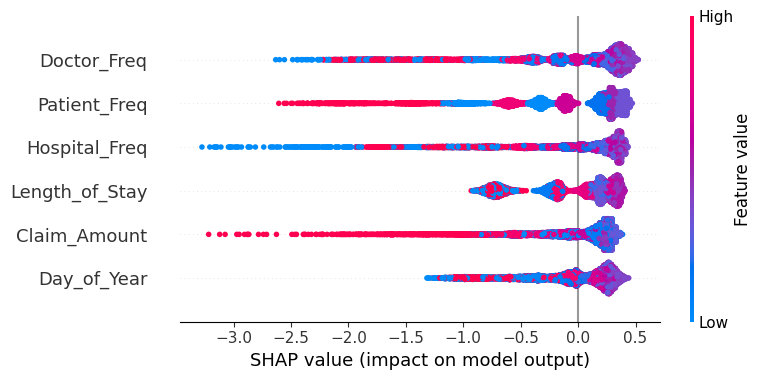

In [68]:
import shap

explainer = shap.TreeExplainer(model)  # use your trained model
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

In [80]:
def load_data(path):
    return pd.read_csv(path)

def train_model(df):
    # train and return model
    return model

def build_graph(df):
    return G

def calculate_scores(df, G):
    return final_scores

In [81]:
!pip install gradio

In [82]:
import pandas as pd

def analyze_claims(file):

    df = pd.read_csv(file.name)

    # ---- Your ML Model Code Here ----
    # model.predict()
    # fraud probability
    # centrality calculation
    # cluster scoring

    # Example output (replace with your real outputs)
    top_doctors = (
        df.groupby("Doctor_ID")["Claim_Amount"]
        .mean()
        .reset_index()
        .sort_values(by="Claim_Amount", ascending=False)
        .head(5)
    )

    return top_doctors

In [84]:
!pip install gradio networkx scikit-learn plotly

In [88]:
import pandas as pd
import numpy as np
import networkx as nx
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import gradio as gr

# ===============================
# LOAD DATASET (NO UPLOAD NEEDED)
# ===============================

df = pd.read_csv("ayushman_synthetic_claims.csv")

# Encode categorical columns
le_doc = LabelEncoder()
le_hosp = LabelEncoder()
le_proc = LabelEncoder()

df["Doctor_ID_enc"] = le_doc.fit_transform(df["Doctor_ID"])
df["Hospital_ID_enc"] = le_hosp.fit_transform(df["Hospital_ID"])
df["Procedure_Code_enc"] = le_proc.fit_transform(df["Procedure_Code"])

# ===============================
# TRAIN FRAUD MODEL
# ===============================

features = ["Claim_Amount", "Length_of_Stay",
            "Doctor_ID_enc", "Hospital_ID_enc", "Procedure_Code_enc"]

X = df[features]
y = df["Fraud_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

df["Fraud_Probability"] = model.predict_proba(X)[:, 1]

# ===============================
# GRAPH INTELLIGENCE
# ===============================

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row["Doctor_ID"], row["Hospital_ID"])

centrality = nx.degree_centrality(G)

df["Centrality"] = df["Doctor_ID"].map(centrality)

df["Combined_Risk"] = (
    df["Fraud_Probability"] * 0.7 +
    df["Centrality"].fillna(0) * 0.3
)

# ===============================
# ANALYSIS FUNCTION
# ===============================

def run_analysis():

    # Top Doctors
    top_docs = (
        df.groupby("Doctor_ID")["Combined_Risk"]
        .mean()
        .reset_index()
        .sort_values(by="Combined_Risk", ascending=False)
        .head(10)
    )

    # Build network plot
    pos = nx.spring_layout(G, seed=42)

    edge_x = []
    edge_y = []

    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5),
        hoverinfo='none',
        mode='lines'
    )

    node_x = []
    node_y = []

    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        marker=dict(size=8),
        hoverinfo='text'
    )

    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(showlegend=False)

    return top_docs, fig

# ===============================
# GRADIO UI
# ===============================

with gr.Blocks() as demo:

    gr.Markdown("# 🛡 ArogyaShield AI")
    gr.Markdown("Fraud Intelligence System for Healthcare Claims")

    run_button = gr.Button("Run Fraud Intelligence")

    output_table = gr.Dataframe()
    output_graph = gr.Plot()

    run_button.click(
        fn=run_analysis,
        inputs=[],
        outputs=[output_table, output_graph]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://21da1a893c7bbab748.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [90]:
!pip install gradio networkx scikit-learn plotly -q

import pandas as pd
import numpy as np
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import gradio as gr

# ===============================
# AUTO LOAD DATASET
# ===============================

df = pd.read_csv("ayushman_synthetic_claims.csv")

# Encode categorical variables
le_doc = LabelEncoder()
le_hosp = LabelEncoder()
le_proc = LabelEncoder()

df["Doctor_ID_enc"] = le_doc.fit_transform(df["Doctor_ID"])
df["Hospital_ID_enc"] = le_hosp.fit_transform(df["Hospital_ID"])
df["Procedure_Code_enc"] = le_proc.fit_transform(df["Procedure_Code"])

# ===============================
# TRAIN MODEL
# ===============================

features = ["Claim_Amount", "Length_of_Stay",
            "Doctor_ID_enc", "Hospital_ID_enc", "Procedure_Code_enc"]

X = df[features]
y = df["Fraud_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

df["Fraud_Probability"] = model.predict_proba(X)[:, 1]

# ===============================
# ANOMALY DETECTION
# ===============================

iso = IsolationForest(contamination=0.05, random_state=42)
df["Anomaly"] = iso.fit_predict(X)
df["Anomaly"] = df["Anomaly"].apply(lambda x: 1 if x == -1 else 0)

# ===============================
# GRAPH INTELLIGENCE
# ===============================

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row["Doctor_ID"], row["Hospital_ID"])

centrality = nx.degree_centrality(G)
df["Centrality"] = df["Doctor_ID"].map(centrality)

df["Combined_Risk"] = (
    df["Fraud_Probability"] * 0.6 +
    df["Centrality"].fillna(0) * 0.3 +
    df["Anomaly"] * 0.1
)

# ===============================
# DASHBOARD FUNCTION
# ===============================

def generate_dashboard(threshold=0.5):

    high_risk = df[df["Combined_Risk"] > threshold]

    total_claims = len(df)
    fraud_cases = int(df["Fraud_Label"].sum())
    fraud_percent = round((fraud_cases / total_claims) * 100, 2)
    high_risk_doctors = high_risk["Doctor_ID"].nunique()

    kpi_text = f"""
Total Claims: {total_claims}
Fraud Cases: {fraud_cases}
Fraud Percentage: {fraud_percent}%
High Risk Doctors: {high_risk_doctors}
"""

    # Top Doctors
    top_docs = (
        df.groupby("Doctor_ID")["Combined_Risk"]
        .mean()
        .reset_index()
        .sort_values(by="Combined_Risk", ascending=False)
        .head(10)
    )

    bar_fig = px.bar(top_docs,
                     x="Doctor_ID",
                     y="Combined_Risk",
                     title="Top 10 Risky Doctors")

    # Fraud Distribution
    pie_fig = px.pie(df,
                     names="Fraud_Label",
                     title="Fraud vs Legit Distribution")

    # Network Graph
    pos = nx.spring_layout(G, seed=42)

    edge_x, edge_y = [], []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5),
        hoverinfo='none',
        mode='lines'
    )

    node_x, node_y = [], []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        marker=dict(size=7),
        hoverinfo='text'
    )

    net_fig = go.Figure(data=[edge_trace, node_trace])
    net_fig.update_layout(title="Doctor-Hospital Network", showlegend=False)

    return kpi_text, bar_fig, pie_fig, net_fig


# ===============================
# UI (AUTO RUN ON LOAD)
# ===============================

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("# 🛡 ArogyaShield AI")
    gr.Markdown("Automated Fraud Intelligence Dashboard")

    threshold_slider = gr.Slider(
        minimum=0,
        maximum=1,
        value=0.5,
        step=0.05,
        label="Risk Threshold"
    )

    with gr.Tabs():
        with gr.Tab("📊 KPIs"):
            kpi_output = gr.Textbox()

        with gr.Tab("📈 Top Doctors"):
            bar_output = gr.Plot()

        with gr.Tab("🥧 Fraud Distribution"):
            pie_output = gr.Plot()

        with gr.Tab("🌐 Network Graph"):
            net_output = gr.Plot()

    demo.load(
        fn=generate_dashboard,
        inputs=threshold_slider,
        outputs=[kpi_output, bar_output, pie_output, net_output]
    )

    threshold_slider.change(
        fn=generate_dashboard,
        inputs=threshold_slider,
        outputs=[kpi_output, bar_output, pie_output, net_output]
    )

demo.launch()

/tmp/ipython-input-362/2423546034.py:152: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4de096ddfbfcce1cdc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
from IPython.display import display, HTML

display(HTML("""
<div style="
background-color:#0B3D91;
color:white;
padding:20px;
border-radius:10px;
text-align:center;
">
<h1>🇮🇳 ArogyaShield AI</h1>
<h3>National Healthcare Fraud Surveillance System</h3>
<p>Ministry of Health & Family Welfare</p>

<a href="https://arogya-shield-ai.base44.app/" target="_blank"
style="
background-color:white;
color:#0B3D91;
padding:10px 20px;
text-decoration:none;
font-weight:bold;
border-radius:5px;
">
Launch Live Application
</a>
</div>
"""))